# 08 - Validation under measurement noise: the honest problem

## Why this notebook exists

Notebook 07 showed 100% accuracy everywhere - not because the model was good, but
because the label leaked into the features (`norm_deviation` = |sum|c_i|^2 - 1| IS the
definition of `is_valid`). See the warning at the top of notebook 07 and the audit.

The deep diagnosis: **on exact amplitudes, validity is computable, not learnable.**
sum_i |c_i|^2 = 1 is a deterministic function of the features. ML has no job there.

## The physical reformulation

In practice one never has exact amplitudes. A state is *reconstructed* by
**tomography** from a finite budget of N measurements. Each component carries a
statistical error - shot noise:

$$\hat{c}_i = c_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2), \qquad \sigma = \frac{1}{2\sqrt{N}}$$

The more you measure (large N), the smaller sigma - precision grows as sqrt(N), never
faster: the universal law of counting statistics.

Consequence: the estimated norm fluctuates around the true one. Near the boundary
||psi||^2 = 1, **the classes genuinely overlap**: deciding becomes a legitimate
statistical problem, with real false positives, real trade-offs, and a difficulty
driven by N.

## Aerospace link

This is exactly the operational problem of embedded quantum sensors: a GNSS satellite
atomic clock, an atom-interferometry gyroscope or a satellite QKD link must **qualify
their states from finite statistics**. The budget N is integration time, energy,
downlink - mission resources. The false-positive rate is mission risk.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qsv.paths import MAIN_DATASET
from qsv.features import add_measurement_noise, compute_features, sigma_from_shots

RANDOM_STATE = 42
%matplotlib inline

df = pd.read_csv(MAIN_DATASET)
print(f"Dataset: {df.shape[0]} states, dim=4, {df['is_valid'].mean():.0%} valid")

Dataset: 10000 states, dim=4, 50% valid


## 1. What noise does to the estimated norm

For each budget N we simulate the tomographic reconstruction of the whole dataset and
look at the distribution of the estimated norm per class.

**Key subtlety - the estimator bias.** Expanding the square:

$$\mathbb{E}\big[\|\hat{\psi}\|^2\big] = \|\psi\|^2 + 2d\,\sigma^2$$

Each of the 2d real components contributes E[eps^2] = sigma^2: noise does not average
out inside a square. A naive validator comparing the estimated norm to 1 without this
correction is systematically offset - the classic instrumentation mistake, the same
one that forces you to calibrate a gyroscope bias before flight.

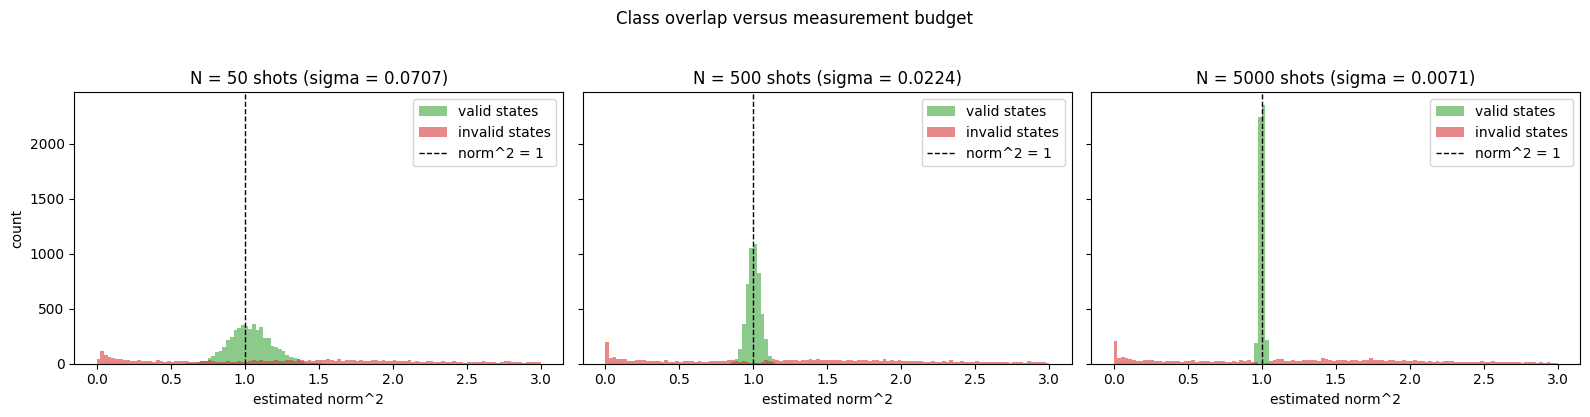

N=   50: estimated norm^2 of VALID states: mean=1.0398 (theoretical bias 2d*sigma^2 = 0.0400), std=0.1442
N=  500: estimated norm^2 of VALID states: mean=1.0040 (theoretical bias 2d*sigma^2 = 0.0040), std=0.0453
N= 5000: estimated norm^2 of VALID states: mean=1.0004 (theoretical bias 2d*sigma^2 = 0.0004), std=0.0143


In [2]:
SHOT_BUDGETS = [50, 500, 5000]
DIM = 4

noisy = {N: add_measurement_noise(df, n_shots=N, seed=RANDOM_STATE) for N in SHOT_BUDGETS}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, N in zip(axes, SHOT_BUDGETS):
    d = noisy[N]
    sigma = sigma_from_shots(N)
    for label, color, name in [(1, "tab:green", "valid"), (0, "tab:red", "invalid")]:
        vals = d.loc[d["is_valid"] == label, "norm_squared"]
        ax.hist(vals, bins=120, range=(0, 3), alpha=0.55, color=color, label=f"{name} states")
    ax.axvline(1.0, color="k", ls="--", lw=1, label="norm^2 = 1")
    ax.set_title(f"N = {N} shots (sigma = {sigma:.4f})")
    ax.set_xlabel("estimated norm^2")
    ax.legend()
axes[0].set_ylabel("count")
fig.suptitle("Class overlap versus measurement budget", y=1.03)
plt.tight_layout(); plt.show()

for N in SHOT_BUDGETS:
    v = noisy[N].loc[noisy[N].is_valid == 1, "norm_squared"]
    print(f"N={N:5d}: estimated norm^2 of VALID states: "
          f"mean={v.mean():.4f} (theoretical bias 2d*sigma^2 = {2*DIM*sigma_from_shots(N)**2:.4f}), "
          f"std={v.std():.4f}")

**Reading.** At N = 50 the distributions overlap widely around the boundary: no
classifier, however sophisticated, can be perfect - physics forbids it, not the
algorithm. At N = 5000 the overlap becomes marginal. The measured bias matches the
2d*sigma^2 prediction: our noise model behaves as theory demands. **N is the
difficulty knob of the problem.**

## 2. Training on noisy data

On noisy data, `norm_squared` and `norm_deviation` are no longer "cheats": they are
**estimators** computed from the observed amplitudes - exactly what an experimentalist
has. The label remains the validity of the *underlying* state: that is what the model
is asked to recover through the noise.

We compare a logistic regression (linear) and a Random Forest, using the features of
`qsv/features.py` (invariant + sensitive, `kind="all"`).

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

results = {}
for N in SHOT_BUDGETS:
    d = noisy[N]
    X = compute_features(d, kind="all")
    y = d["is_valid"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    # Scaling: needed for the logistic regression (gradient descent, isotropic
    # regularization) - useless for the Random Forest, which is invariant under
    # monotone per-feature transformations (a conceptual error of notebook 07).
    scaler = StandardScaler().fit(X_tr)

    logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    logreg.fit(scaler.transform(X_tr), y_tr)
    p_lr = logreg.predict_proba(scaler.transform(X_te))[:, 1]

    rf = RandomForestClassifier(n_estimators=100, max_depth=None,
                                random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    p_rf = rf.predict_proba(X_te)[:, 1]

    results[N] = {
        "y_test": y_te,
        "acc_lr": accuracy_score(y_te, p_lr > 0.5),
        "acc_rf": accuracy_score(y_te, p_rf > 0.5),
        "auc_rf": roc_auc_score(y_te, p_rf),
        "proba_rf": p_rf,
    }
    print(f"N={N:5d} | LogReg: acc={results[N]['acc_lr']:.4f} | "
          f"RF: acc={results[N]['acc_rf']:.4f} AUC={results[N]['auc_rf']:.4f}")

N=   50 | LogReg: acc=0.6028 | RF: acc=0.9060 AUC=0.9398


N=  500 | LogReg: acc=0.6020 | RF: acc=0.9736 AUC=0.9866


N= 5000 | LogReg: acc=0.6060 | RF: acc=0.9976 AUC=0.9987


**Honest numbers at last - and an instructive failure.** Accuracy is no longer
1.0000: it grows with N and saturates toward 1 as the noise vanishes - the expected
behaviour of a genuine statistical problem.

The most instructive result is **the collapse of the logistic regression (~60%,
barely above chance)** while the forest exceeds 90%. Two combined causes:

1. **Non-linear decision geometry**: the "valid" class lives in a *band*
   norm^2 in [1-t, 1+t]. A linear boundary cannot carve out an interval bounded on
   both sides in raw feature space; a tree does it with two splits.
2. **Heavy tails**: extreme states push `purity_raw` up to ~1e8. Mean/std
   standardization is crushed by these outliers: for the vast majority of points the
   standardized features collapse near zero and the gradient has no usable signal.

**Lesson**: data *representation* matters more than algorithmic power. The next
section proves it by contradiction: with the right statistic (a single well-built
feature), a one-parameter threshold suffices.

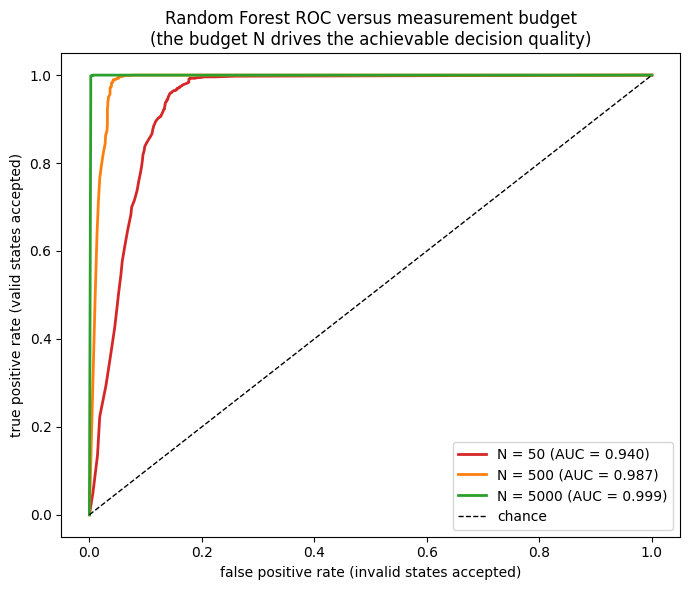

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {50: "tab:red", 500: "tab:orange", 5000: "tab:green"}
for N in SHOT_BUDGETS:
    fpr, tpr, _ = roc_curve(results[N]["y_test"], results[N]["proba_rf"])
    ax.plot(fpr, tpr, color=colors[N], lw=2, label=f"N = {N} (AUC = {results[N]['auc_rf']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax.set_xlabel("false positive rate (invalid states accepted)")
ax.set_ylabel("true positive rate (valid states accepted)")
ax.set_title("Random Forest ROC versus measurement budget\n(the budget N drives the achievable decision quality)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 3. The referee: comparison with the optimal statistical test

Decision theory says the sufficient statistic for this problem is the estimated norm.
The (structurally) optimal test is a **bias-corrected two-sided threshold**:

$$\text{reject validity if } \big|\,\|\hat{\psi}\|^2 - 1 - 2d\sigma^2\,\big| > t$$

One single parameter t, fitted on the train set. If our 8-feature ML models cannot
beat this 1-parameter test, then all the useful information lives in the norm - which
is what the physics already told us.

In [5]:
from sklearn.tree import DecisionTreeClassifier

print(f"{'N':>6} | {'threshold test (1 param)':>25} | {'LogReg':>8} | {'RF':>8}")
print("-" * 58)
for N in SHOT_BUDGETS:
    d = noisy[N]
    sigma = sigma_from_shots(N)
    stat = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("t_stat")
    y = d["is_valid"]
    s_tr, s_te, y_tr, y_te = train_test_split(
        stat, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(s_tr, y_tr)
    acc_stump = accuracy_score(y_te, stump.predict(s_te))
    print(f"{N:>6} | {acc_stump:>25.4f} | {results[N]['acc_lr']:>8.4f} | {results[N]['acc_rf']:>8.4f}")

     N |  threshold test (1 param) |   LogReg |       RF
----------------------------------------------------------
    50 |                    0.9132 |   0.6028 |   0.9060
   500 |                    0.9724 |   0.6020 |   0.9736
  5000 |                    0.9972 |   0.6060 |   0.9976


## Conclusion

Three lessons, from technical to fundamental:

1. **The one-parameter test is statistically tied with the Random Forest at every N**
   (gaps below 0.5 point, within sampling noise - it even wins at N=50) and crushes
   the logistic regression. All the validity information lives in the estimated norm:
   the 8 features and the 100-tree forest add nothing beyond what the structure of the
   problem contains. Understanding the problem before modelling it would have saved an
   entire notebook - the lesson of notebook 07.

2. **Performance is now driven by the physics** (the budget N), not the algorithm. For
   a systems engineer the interesting question is no longer "which model?" but
   "**what minimum N for a contractual false-positive rate?**" - measurement-budget
   sizing, exactly like sizing the integration time of a GNSS atomic clock to meet a
   stability spec, or the photon count of a satellite QKD session to bound the error
   rate.

3. **ML finds its rightful place**: here, a verification baseline. It becomes truly
   useful when the problem gets harder - correlated noise, systematic calibration
   drift, classifying the *cause* of invalidity, variable dimensions. That is the
   milestone-4 roadmap (notebooks 09-12).

*Related modules: `qsv/features.py` (features and noise), `qsv/data_generation.py`
(F2 boundary guarantee). Tests: `tests/test_features.py`.*